In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from utils import *
from pylops.basicoperators import *

In [2]:
moomba_test_path = './data/test_cubes/F3_test_2.npy'
Unet_pred_path = './notebook/results/unet_pred_f3_2_sx5_sy5_regular.npy'
UFNO_pred_path = './notebook/results/ufno_pred_f3_2_sx5_sy5_regular.npy'
label = np.load(f'{moomba_test_path}')
Unet_pred = np.load(f'{Unet_pred_path}')
UFNO_pred = np.load(f'{UFNO_pred_path}')
Convention_pred = np.copy(Unet_pred)

In [3]:
def regular_missing(cube, n, mode="inline"):
    """
    Regular missing along axis directions.
      mode: "inline" | "crossline" | "both" (intersection) | "all" (intersection of all 3)
    Keep every n-th trace (1/n kept) with a random offset per axis.
    """
    in1, in2, in3 = (cube.T).shape
    mask = np.ones((in1, in2, in3), dtype=np.float32)

    if mode in ["inline", "both", "all"]:
        o1 = np.random.randint(0, n)
        kept1 = list(range(o1, in1, n))
        m1 = np.zeros_like(mask); m1[kept1, :, :] = 1.0
        mask = m1 if mode == "inline" else mask * m1

    if mode in ["crossline", "both", "all"]:
        o2 = np.random.randint(0, n)
        kept2 = list(range(o2, in2, n))
        m2 = np.zeros_like(mask); m2[:, kept2, :] = 1.0
        mask = m2 if mode == "crossline" else mask * m2

    if mode == "all":
        o3 = np.random.randint(0, n)
        kept3 = list(range(o3, in3, n))
        m3 = np.zeros_like(mask); m3[:, :, kept3] = 1.0
        mask = mask * m3

    return cube * mask

def regular_line_grid_mask_xy(shape, strides=(4,4), offsets=(0,0), dtype=np.float32):
    """
    Generate a mask with regular missing along both inline (X) and crossline (Y).
    - strides = (sx, sy): keep every sx-th inline and every sy-th crossline
    - offsets = (ox, oy): starting offsets to avoid always beginning at 0
    - The Z dimension is fully preserved (no subsampling along time/depth).
    """
    nx, ny, nz = shape
    sx, sy = strides
    ox, oy = offsets
    if sx < 1 or sy < 1:
        raise ValueError("sx, sy must be >= 1")

    ox %= sx
    oy %= sy

    # Create a 2D mask in XY plane
    mask2d = np.zeros((ny, nz), dtype=dtype)
    # Keep full inline lines (x ≡ ox mod sx)
    mask2d[ox::sx, :] = 1.0
    # Keep full crossline lines (y ≡ oy mod sy)
    mask2d[:, oy::sy] = 1.0

    # Expand to 3D by repeating along Z
    mask3d = np.repeat(mask2d[None, :, :], nx, axis=0).astype(dtype)
    return mask3d

<Figure size 600x600 with 0 Axes>

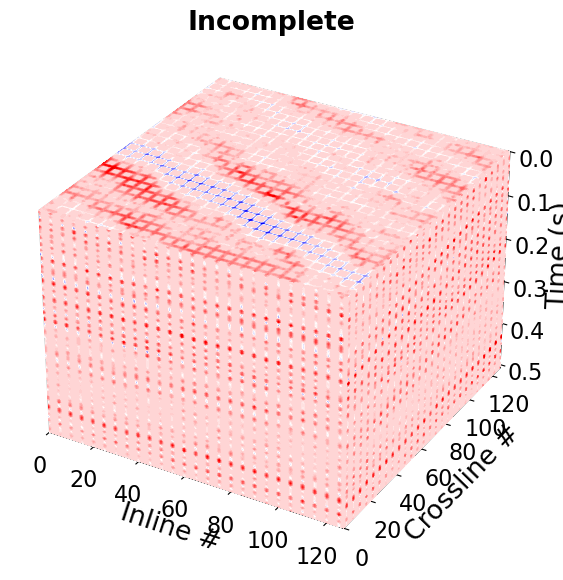

In [4]:
# [in1, in2, in3] = label.shape
# # the ratio of missing trace equal to 1-ratio
# ratio = 0.25

# ## build the input data
# [in1, in2, in3] = label.shape
# ## generate random mask
# iava, iavarec = irregular2(in1, in2, in3, perc_sub=ratio, seed=10)
# # Create restriction operator
# Rop = Restriction(dims=in1*in2*in3, iava=iava, dtype='float64')
# datamasked = Rop.H*Rop*label.ravel()
# mask = Rop.H*Rop*np.ones_like(label).ravel()
# mask = mask.reshape(in1, in2, in3)
# frand_mask_cube = label.T*mask
# test_data = frand_mask_cube.T

sx, sy = 5, 5
ox = random.randrange(sx)
oy = random.randrange(sy)
mask = regular_line_grid_mask_xy(label.shape, strides=(sx, sy), offsets=(ox, oy))
test_data = label * mask

cube_visual(test_data, dt=0.004, dz=1, xlabel="Inline #", ylabel="Crossline #", zlabel="Time (s)", title='Incomplete', 
            save_path=False)

# sec_num = 2
# trace_num = 10
# gap_mask_cube = large_gap_missing_3d(label, direction='inline', section_num=sec_num, trace_each_gap=trace_num, rand_seed=202411)
# test_data = gap_mask_cube

In [5]:
# Define spatial parameters
deltaz = 0.004
deltax = deltay = 1
zmin = xmin = ymin = 0

cube_shape = label.shape
xmax = cube_shape[0] * deltax
ymax = cube_shape[1] * deltay
zmax = cube_shape[2] * deltaz

# Generate coordinate arrays
x = np.linspace(xmin, xmax, cube_shape[0], endpoint=True)
y = np.linspace(ymin, ymax, cube_shape[1], endpoint=True)
z = np.linspace(zmin, zmax, cube_shape[2], endpoint=True)
print(x.shape)

# Create meshgrid
Z, X, Y = np.meshgrid(z, x, y, indexing='ij')

(128,)


In [6]:
import pyortho as lo #lo: local orthogonalization

## prepare paramters for ortho
rect=[10,10,10];
eps=0;
niter=20;
verb=1;


simi_unet=lo.localsimic(label,label-Unet_pred,[5,5,5],niter,eps,verb);
simi_ufno=lo.localsimic(label,label-UFNO_pred,[5,5,5],niter,eps,verb);
simi_convention=lo.localsimic(label,label-Convention_pred,[5,5,5],niter,eps,verb);

128 128 128 5 5 5 20 0 1
128 128 128 5 5 5 20 0 1
128 128 128 5 5 5 20 0 1
n1=128,n2=128,n3=128,r1=5,r2=5,r3=5
niter=20,eps=0,verb=1
dim=3,dim1=2
nd=2097152
iteration 0 res: 0.998515 grad: 0.000000
iteration 1 res: 0.785348 grad: 0.822941
iteration 2 res: 0.731452 grad: 0.168833
iteration 3 res: 0.704101 grad: 0.067595
iteration 4 res: 0.695598 grad: 0.039172
iteration 5 res: 0.692598 grad: 0.017060
iteration 6 res: 0.691405 grad: 0.005719
iteration 7 res: 0.691377 grad: 0.003996
iteration 8 res: 0.691474 grad: 0.001206
iteration 9 res: 0.691596 grad: 0.000385
iteration 10 res: 0.691626 grad: 0.000121
iteration 11 res: 0.691586 grad: 0.000040
iteration 12 res: 0.691560 grad: 0.000013
iteration 13 res: 0.691538 grad: 0.000005
iteration 14 res: 0.691533 grad: 0.000001
convergence in 15 iterations, alpha=0.408284, gd=5.91142e-07 
iteration 0 res: 0.997997 grad: 0.000000
iteration 1 res: 0.799919 grad: 0.282576
iteration 2 res: 0.744474 grad: 0.123527
iteration 3 res: 0.716752 grad: 0.0465

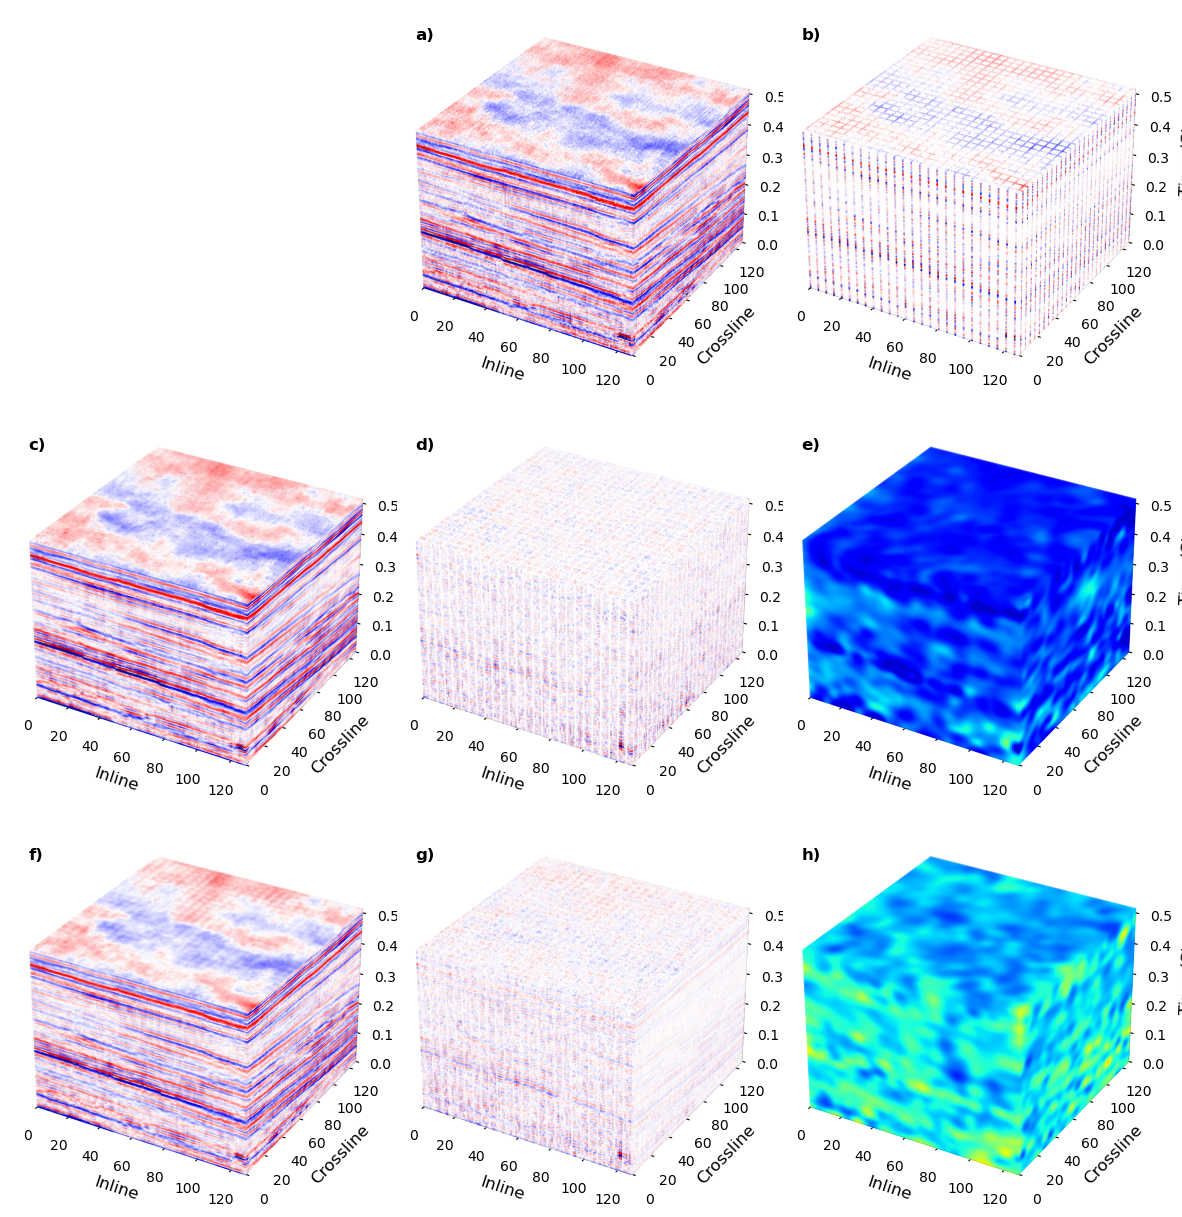

In [7]:
# Data for visualization
data = [
    label, test_data, UFNO_pred, (label - UFNO_pred), simi_ufno, Unet_pred,
    (label - Unet_pred), simi_unet
]

# Create figure with smaller size
fig = plt.figure(figsize=(12, 12))

# Create subplots with scatter plotting
for i in range(8):
    ax = fig.add_subplot(3, 3, i + 2, projection='3d')
    # Downsample heavily for speed (every 20th point)
    step = 1
    idx = np.arange(0, data[i].size, step)
    # Use jet colormap for figures e and h (indices 4 and 7 for Simi UFNO and Simi Unet)
    if i in [4, 7]:  # Simi UFNO and Simi Unet
        ax.scatter(
            X.flatten()[idx], Y.flatten()[idx], Z.flatten()[idx],
            c=data[i].flatten()[idx], cmap='jet', vmin=0, vmax=1, s=0.5
        )
    else:
        ax.scatter(
            X.flatten()[idx], Y.flatten()[idx], Z.flatten()[idx],
            c=data[i].flatten()[idx], cmap='seismic', vmin=-4, vmax=4, s=0.5
        )
    # Set axis labels with smaller fontsize
    ax.set_xlabel('Inline', fontsize=12)
    ax.set_ylabel('Crossline', fontsize=12)
    ax.set_zlabel('Time (S)', fontsize=12)
    # Set tick label fontsize
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.invert_zaxis()
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.text2D(0.05, 0.95, f"{chr(97 + i)})", transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)

# Adjust layout
fig.subplots_adjust(left=0.0, right=0.96, top=1, bottom=0.01, wspace=0.02, hspace=0.11)

# Save figure
plt.savefig(f'./figs/tgrs_results/F3_test_sx{sx}_sy{sy}_regular_missing_comp.png')

plt.show()

In [19]:
# plt.savefig('moomba_cube_visual_compare_1.png')
# plt.savefig('moomba_cube_visual_compare_1.pdf')

<Figure size 640x480 with 0 Axes>

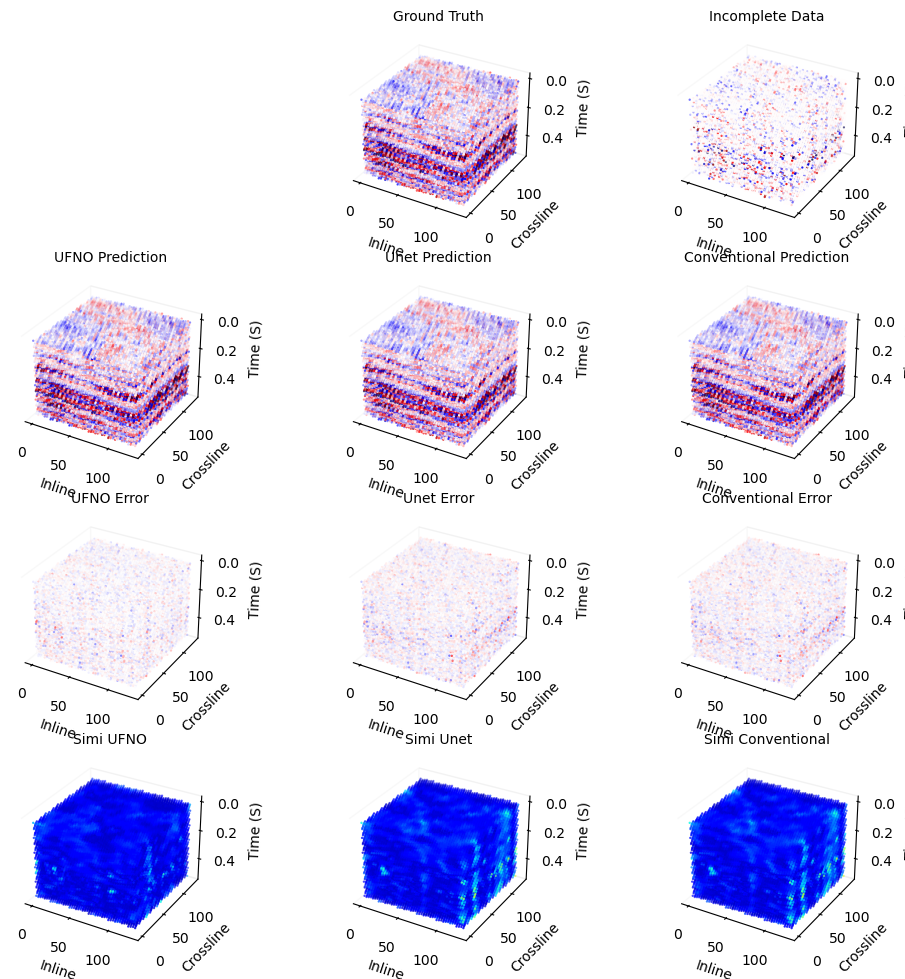

In [9]:
# Data for visualization
data = [
    label, test_data, UFNO_pred, Unet_pred, Convention_pred,
    (label - UFNO_pred), (label - Unet_pred), (label - Convention_pred),
    simi_ufno, simi_unet, simi_convention
]
titles = [
    'Ground Truth', 'Incomplete Data', 'UFNO Prediction', 'Unet Prediction',
    'Conventional Prediction', 'UFNO Error', 'Unet Error', 'Conventional Error',
    'Simi UFNO', 'Simi Unet', 'Simi Conventional'
]

# Create figure
fig = plt.figure(figsize=(12, 12))

# Create subplots with scatter plotting
seismic_sc = None
simi_sc = None
for i in range(11):
    ax = fig.add_subplot(4, 3, i + 2, projection='3d')
    # Downsample for speed (every 10th point)
    step = 25
    idx = np.arange(0, data[i].size, step)
    # Scatter plot with appropriate colormap
    if i >= 8:  # Last three subplots (Simi UFNO, Simi Unet, Simi Conventional)
        sc = ax.scatter(
            X.flatten()[idx], Y.flatten()[idx], Z.flatten()[idx],
            c=data[i].flatten()[idx], cmap='jet', vmin=0, vmax=1, s=0.5
        )
        if i == 8:  # Store scatter object for similarity colorbar
            simi_sc = sc
    else:
        sc = ax.scatter(
            X.flatten()[idx], Y.flatten()[idx], Z.flatten()[idx],
            c=data[i].flatten()[idx], cmap='seismic', vmin=-5, vmax=5, s=0.5
        )
        if i == 0:  # Store scatter object for seismic colorbar
            seismic_sc = sc
    ax.set_xlabel('Inline')
    ax.set_ylabel('Crossline')
    ax.set_zlabel('Time (S)')
    ax.set_title(titles[i], fontsize=10)
    ax.invert_zaxis()
    # Remove grid/mesh
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

# # Add colorbar for seismic data
# cbar_seismic = fig.colorbar(seismic_sc, ax=fig.get_axes(), location='right', shrink=0.2, pad=0.05)
# cbar_seismic.set_label('Amplitude', fontsize=10)

# # Add colorbar for similarity data
# cbar_simi = fig.colorbar(simi_sc, ax=fig.get_axes(), location='bottom', shrink=0.2, pad=0.05)
# cbar_simi.set_label('Similarity', fontsize=10)

# Adjust layout
# plt.tight_layout()


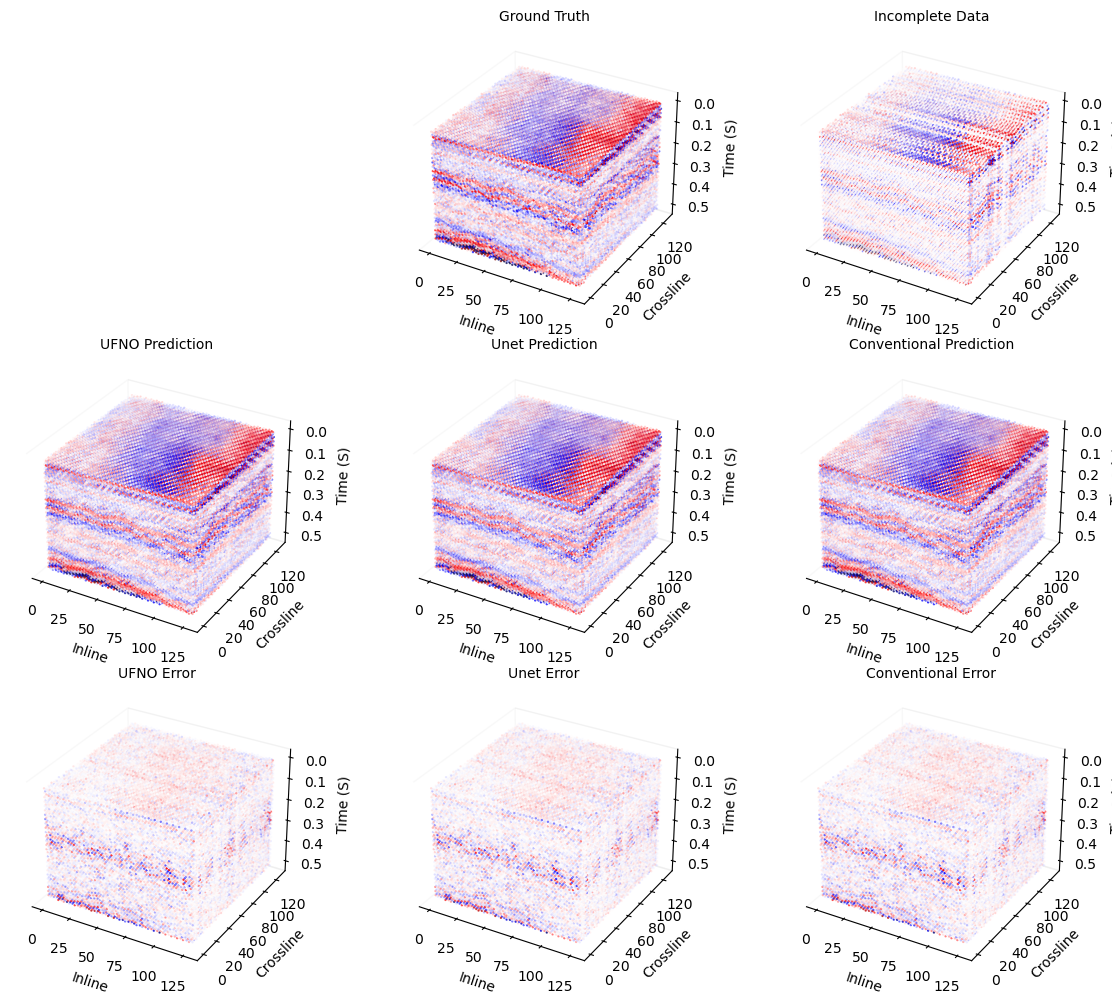

In [6]:
# Data for visualization
data = [
    label, test_data, UFNO_pred, Unet_pred, Convention_pred,
    (label - UFNO_pred), (label - Unet_pred), (label - Convention_pred)
]
titles = [
    'Ground Truth', 'Incomplete Data', 'UFNO Prediction', 'Unet Prediction',
    'Conventional Prediction', 'UFNO Error', 'Unet Error', 'Conventional Error'
]

# Create figure
fig = plt.figure(figsize=(12, 10))

# Create subplots with scatter plotting
for i in range(8):
    ax = fig.add_subplot(3, 3, i + 2, projection='3d')
    # Downsample for speed (every 10th point for balance)
    step = 10
    idx = np.arange(0, data[i].size, step)
    ax.scatter(
        X.flatten()[idx], Y.flatten()[idx], Z.flatten()[idx],
        c=data[i].flatten()[idx], cmap='seismic', vmin=-5, vmax=5, s=0.5
    )
    ax.set_xlabel('Inline')
    ax.set_ylabel('Crossline')
    ax.set_zlabel('Time (S)')
    ax.set_title(titles[i], fontsize=10)
    ax.invert_zaxis()
    # Remove grid/mesh
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

# Adjust layout
plt.tight_layout()
